In [ ]:
import pandas as pd
path="/shares/sinha/epallapotu/blood_expression_project/41586_2023_6802_MOESM5_ESM.xlsx"
supp3 = pd.read_excel(path, sheet_name='ST3')


In [ ]:
print(supp3.columns.tolist())


['Somamer', 'SeqId', 'SeqIdVersion', 'SomaId', 'TargetFullName', 'Target', 'UniProt', 'EntrezGeneID', 'EntrezGeneSymbol', 'GtexName', 'Organism', 'Units', 'GtexFoldChange', 'GtexOrgan', 'GtexEnriched', 'GeneName', 'GeneNameUnique']


In [ ]:
import pandas as pd

# === Load Supplementary Table 3 ===
supp3.columns = [col.strip() for col in supp3.columns]     # Clean column names
supp3['GeneName'] = supp3['GeneName'].str.upper()          # Clean gene names

# === Clean GtexOrgan field ===
def extract_organs(raw_entry):
    if pd.isna(raw_entry):
        return []
    return list(set(x.strip() for x in str(raw_entry).split(',') if x and x.lower() != "nan"))

supp3['Cleaned_Organs'] = supp3['GtexOrgan'].apply(extract_organs)

# === Map vague GtexOrgan values to GTEx tissue names ===
organ_map = {
    "Male": ["Testis", "Prostate"],
    "Female": ["Ovary", "Uterus", "Vagina", "Breast - Mammary Tissue"],
    "Muscle": ["Muscle - Skeletal"],
    "Brain": ["Brain - Cortex", "Brain - Cerebellum"],
    "Esophagus": ["Esophagus - Mucosa", "Esophagus - Muscularis", "Esophagus - Gastroesophageal Junction"],
    "Heart": ["Heart - Left Ventricle", "Heart - Atrial Appendage"],
    "Artery": ["Artery - Aorta", "Artery - Tibial", "Artery - Coronary"],
    "Intestine": ["Small Intestine - Terminal Ileum", "Colon - Sigmoid", "Colon - Transverse"],
    "Adipose": ["Adipose - Subcutaneous"],
    "Kidney": ["Kidney - Cortex"],
    "Salivary": [],
    "Pituitary": ["Pituitary"],
    "Thyroid": ["Thyroid"],
    "Pancreas": ["Pancreas"],
    "Liver": ["Liver"],
    "Lung": ["Lung"],
    "Spleen": ["Spleen"],
    "Bladder": [],
    "Skin": [],
    "Immune": ["Spleen"]
}

def map_to_gtex_tissues(organ_list, mapping):
    gtex_match = []
    for organ in organ_list:
        gtex_match.extend(mapping.get(organ, []))
    return list(set(gtex_match))

supp3['Mapped_GTEx_Tissues'] = supp3['Cleaned_Organs'].apply(lambda x: map_to_gtex_tissues(x, organ_map))

# === Load delta score data ===
delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
unique_tissues = delta_data["tissue"].unique()

# === Loop through tissues and match top genes ===
for tissue in unique_tissues:
    print(f"\n--- {tissue.upper()} ---")

    # Load top gene list for this tissue as a list of uppercase gene names
    file_path = f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_geneDescription.txt"
    top_gene_names = pd.read_csv(file_path, header=None)[0].str.upper().head(150).tolist()

    # Filter supp3 to matching genes
    matches = supp3[supp3['GeneName'].isin(top_gene_names)].copy()

    # Check whether mapped GTEx tissues include this tissue
    def matches_tissue(mapped_tissues, tissue_name):
        return any(tissue_name.lower() in mt.lower() for mt in mapped_tissues)

    matches['Is_Tissue_Expressed'] = matches['Mapped_GTEx_Tissues'].apply(lambda x: matches_tissue(x, tissue))

    matches_tissue_specific = matches[matches['Is_Tissue_Expressed']]

    if 'GtexEnriched' in matches_tissue_specific.columns:
        matches_tissue_enriched = matches_tissue_specific[matches_tissue_specific['GtexEnriched'] == 'True']
    else:
        matches_tissue_enriched = pd.DataFrame()


    # Output stats
    print(f"Top genes: {len(top_gene_names)}")
    print(f"Matched in Supp3: {len(matches)}")
    print(f"Expressed in {tissue}: {len(matches_tissue_specific)}")
    print(f"Enriched in {tissue}: {len(matches_tissue_enriched)}")

    if not matches_tissue_enriched.empty:
        print(matches_tissue_enriched[['GeneName', 'GtexOrgan', 'GtexFoldChange']])



--- ADIPOSE - SUBCUTANEOUS ---
Top genes: 150
Matched in Supp3: 23
Expressed in Adipose - Subcutaneous: 0
Enriched in Adipose - Subcutaneous: 0

--- ADRENAL GLAND ---
Top genes: 150
Matched in Supp3: 48
Expressed in Adrenal Gland: 0
Enriched in Adrenal Gland: 0

--- ARTERY - AORTA ---
Top genes: 150
Matched in Supp3: 34
Expressed in Artery - Aorta: 2
Enriched in Artery - Aorta: 0

--- ARTERY - CORONARY ---
Top genes: 150
Matched in Supp3: 53
Expressed in Artery - Coronary: 0
Enriched in Artery - Coronary: 0

--- ARTERY - TIBIAL ---
Top genes: 150
Matched in Supp3: 34
Expressed in Artery - Tibial: 3
Enriched in Artery - Tibial: 0

--- BRAIN - CEREBELLUM ---
Top genes: 150
Matched in Supp3: 42
Expressed in Brain - Cerebellum: 3
Enriched in Brain - Cerebellum: 1
     GeneName GtexOrgan     GtexFoldChange
4929   SPOCK3     Brain  4.946036929559076

--- BRAIN - CORTEX ---
Top genes: 150
Matched in Supp3: 34
Expressed in Brain - Cortex: 8
Enriched in Brain - Cortex: 2
     GeneName GtexOrga

Number of enriched genes for Adipose - Subcutaneous: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


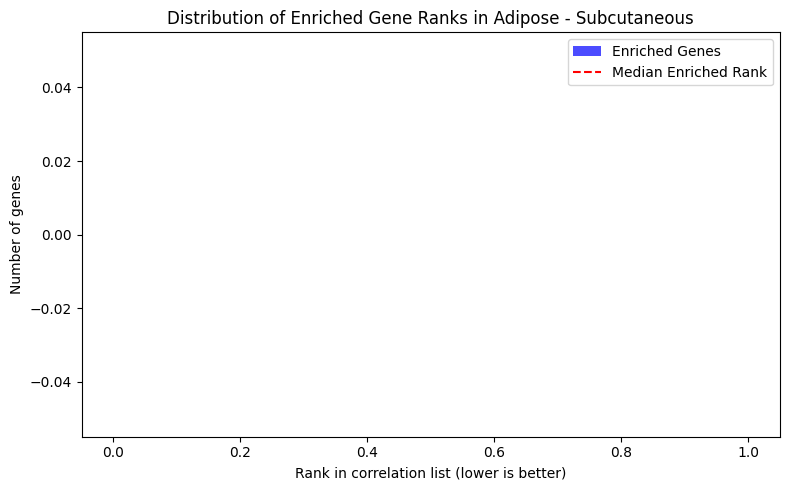

Number of enriched genes for Adrenal Gland: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


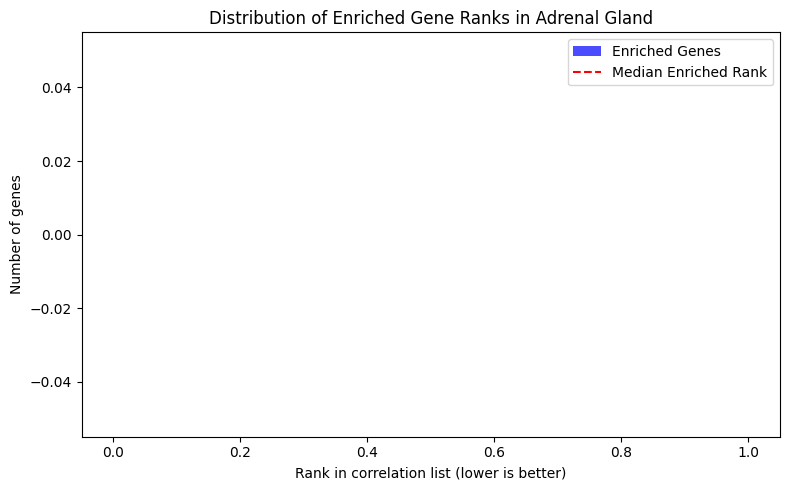

Number of enriched genes for Artery - Aorta: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


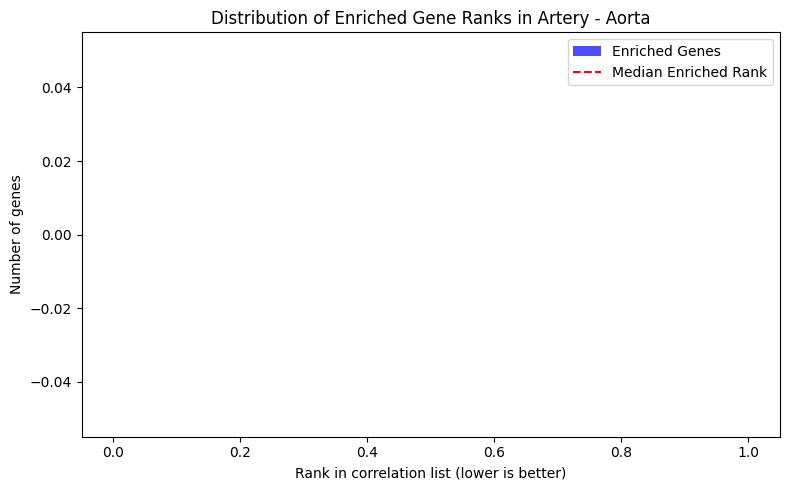

Number of enriched genes for Artery - Coronary: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


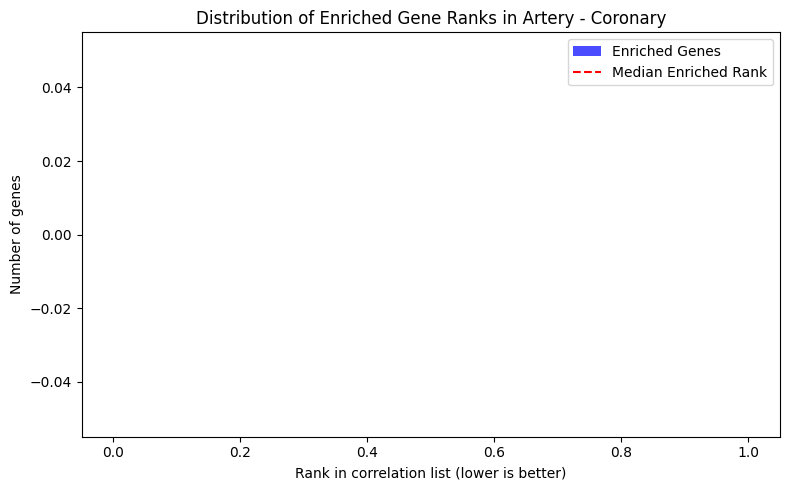

Number of enriched genes for Artery - Tibial: 0


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


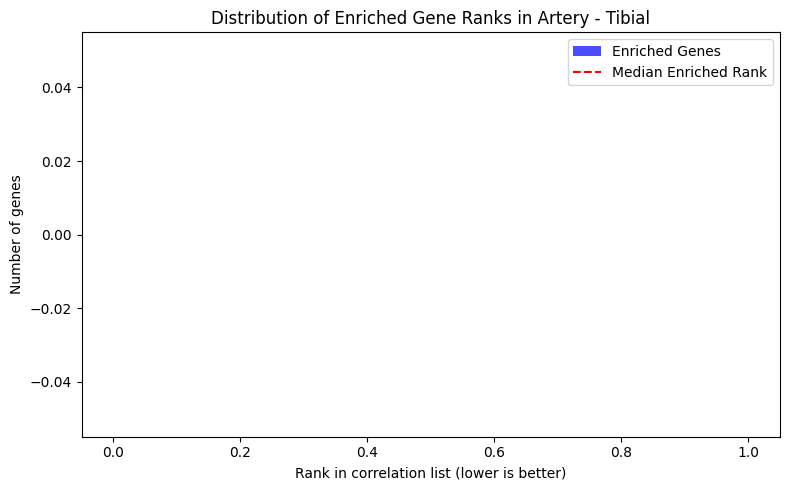

Number of enriched genes for Brain - Cerebellum: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


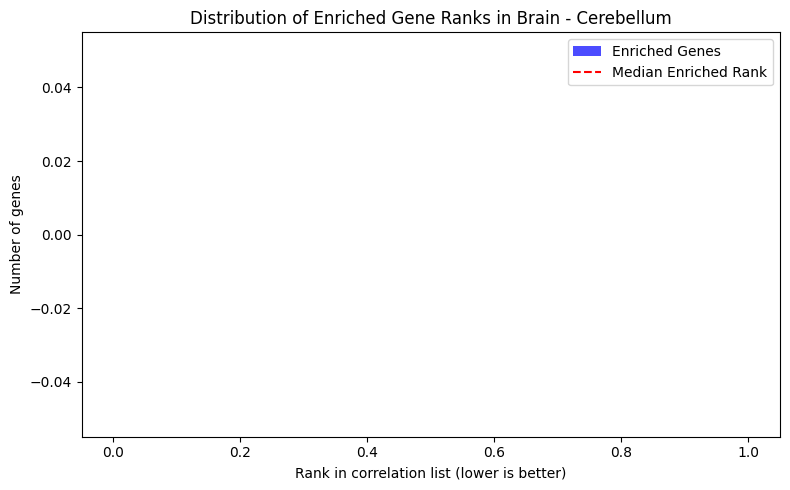

Number of enriched genes for Brain - Cortex: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


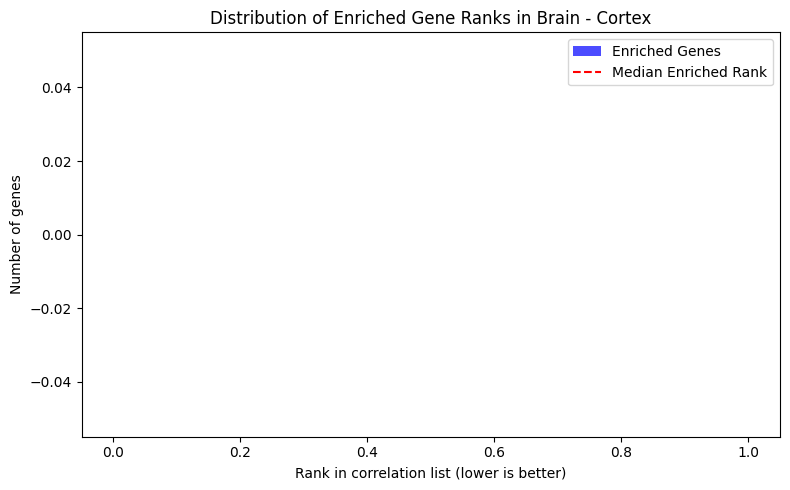

Number of enriched genes for Breast - Mammary Tissue: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


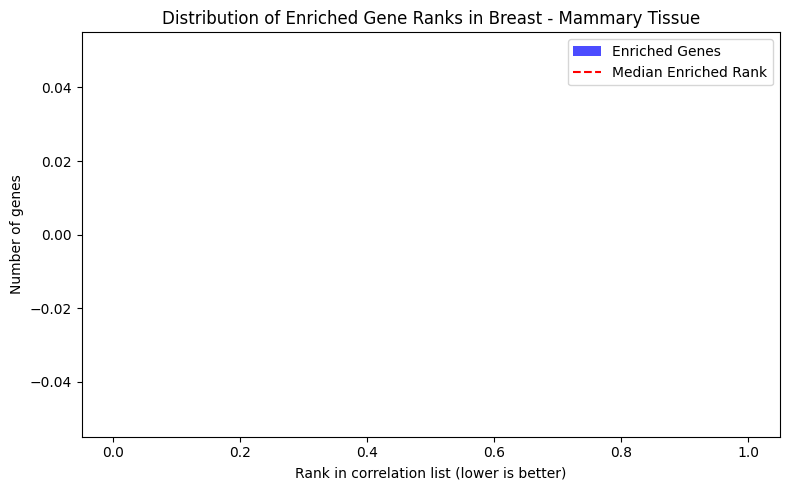

Number of enriched genes for Colon - Sigmoid: 0


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


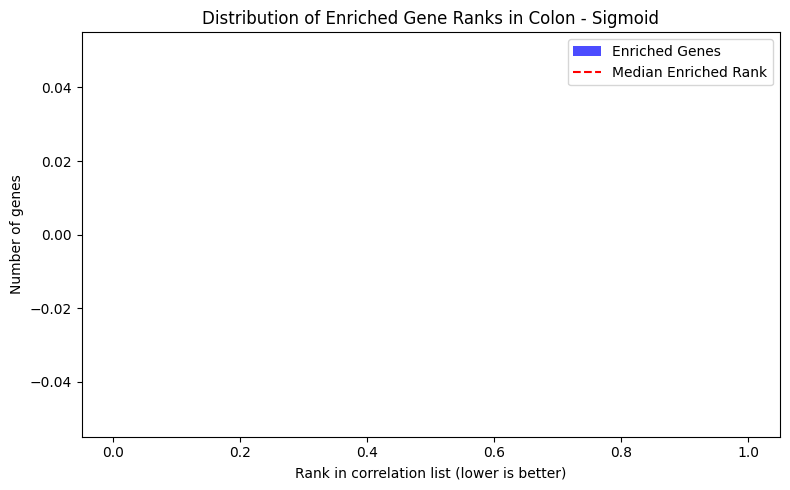

Number of enriched genes for Colon - Transverse: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


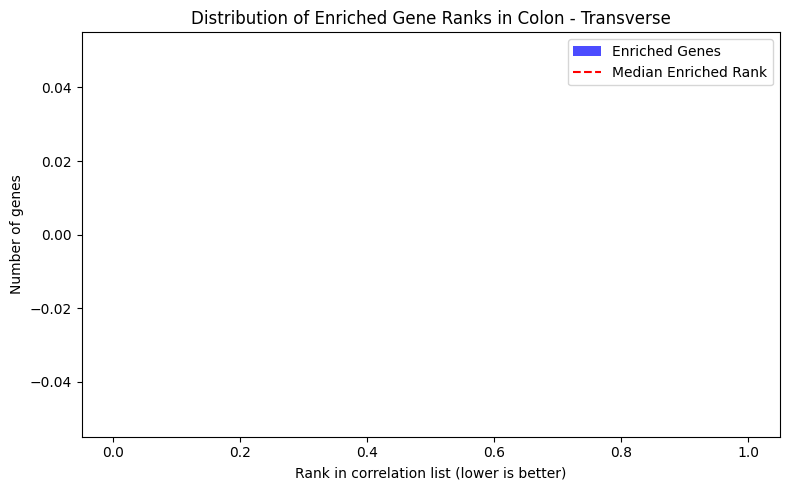

Number of enriched genes for Esophagus - Gastroesophageal Junction: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


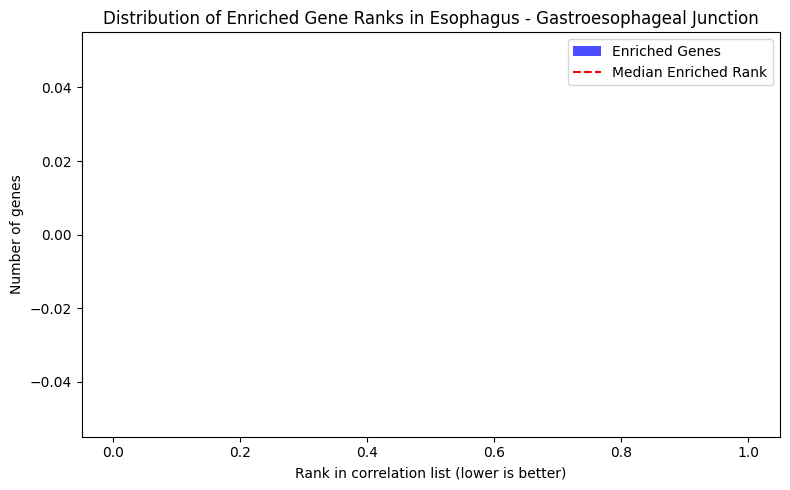

Number of enriched genes for Esophagus - Mucosa: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


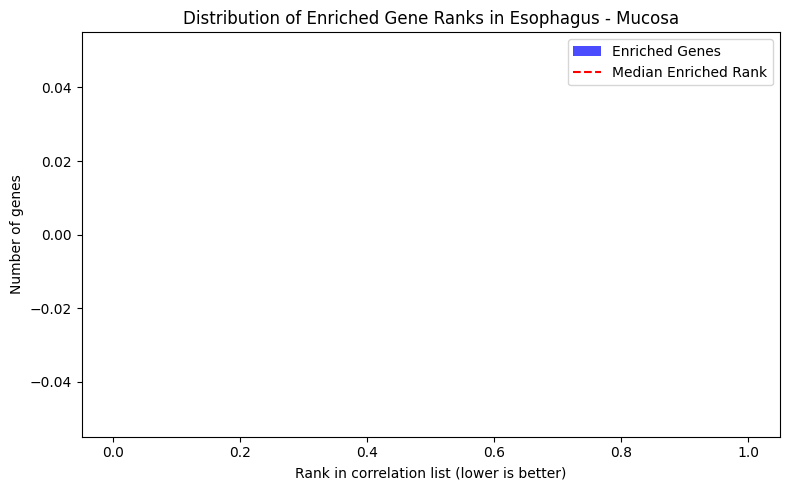

Number of enriched genes for Esophagus - Muscularis: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


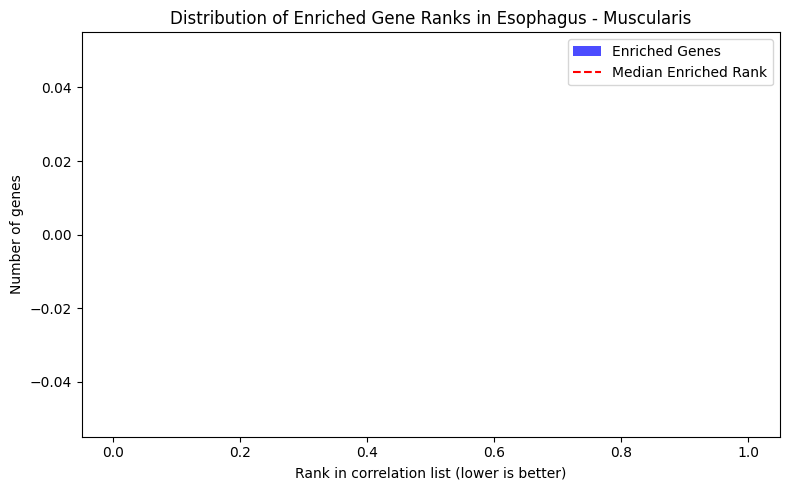

Number of enriched genes for Heart - Atrial Appendage: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


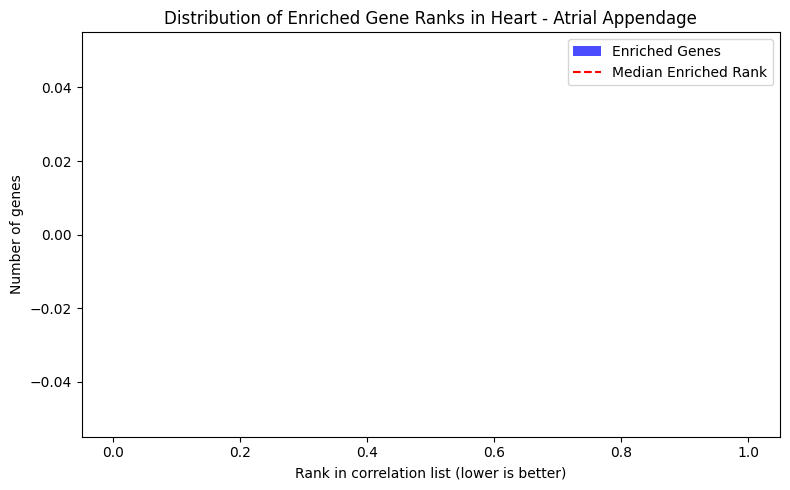

Number of enriched genes for Heart - Left Ventricle: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


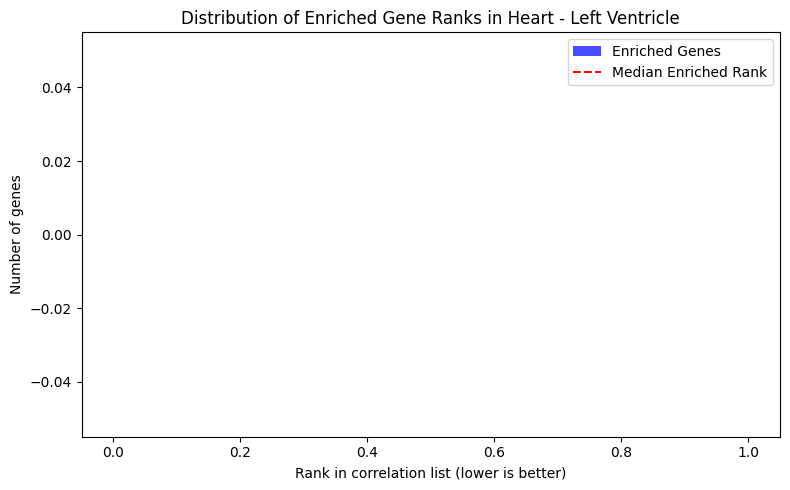

Number of enriched genes for Kidney - Cortex: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


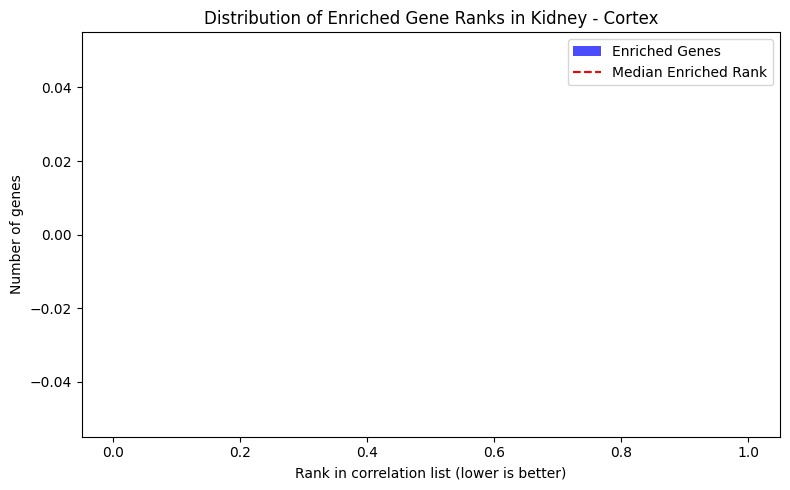

Number of enriched genes for Liver: 106
Enriched genes found in correlation file: 105
KS statistic: 0.4627, p-value: 6.5691e-21


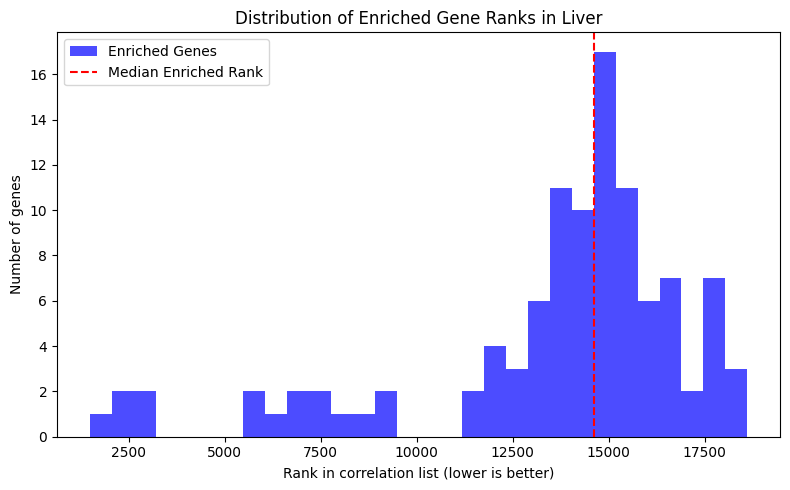

Number of enriched genes for Lung: 9
Enriched genes found in correlation file: 9
KS statistic: 0.3662, p-value: 1.3730e-01


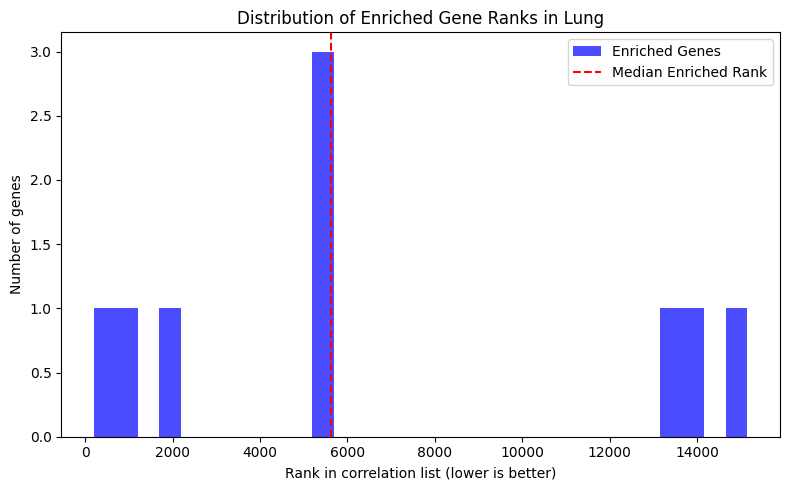

Number of enriched genes for Muscle - Skeletal: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


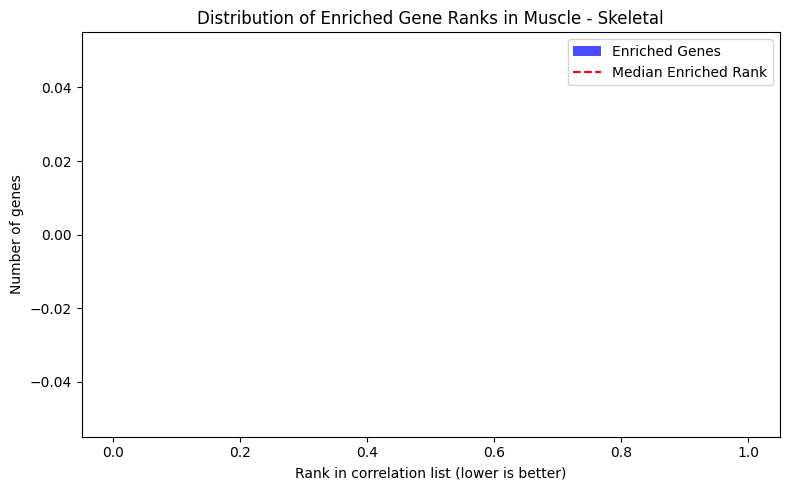

Number of enriched genes for Nerve - Tibial: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


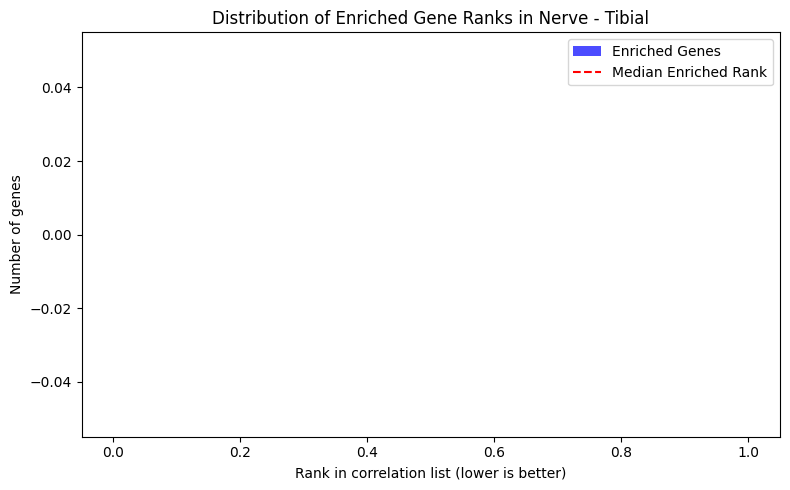

Number of enriched genes for Ovary: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


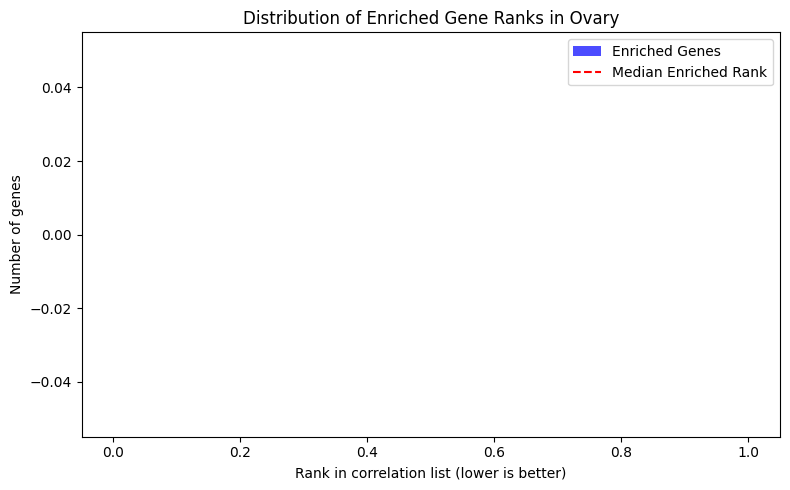

Number of enriched genes for Pancreas: 35
Enriched genes found in correlation file: 35
KS statistic: 0.2643, p-value: 1.1997e-02


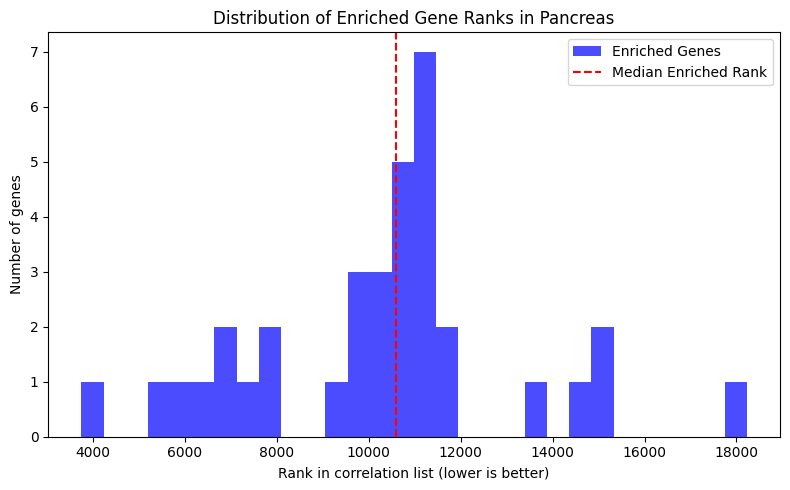

Number of enriched genes for Pituitary: 10
Enriched genes found in correlation file: 10
KS statistic: 0.5878, p-value: 8.1097e-04


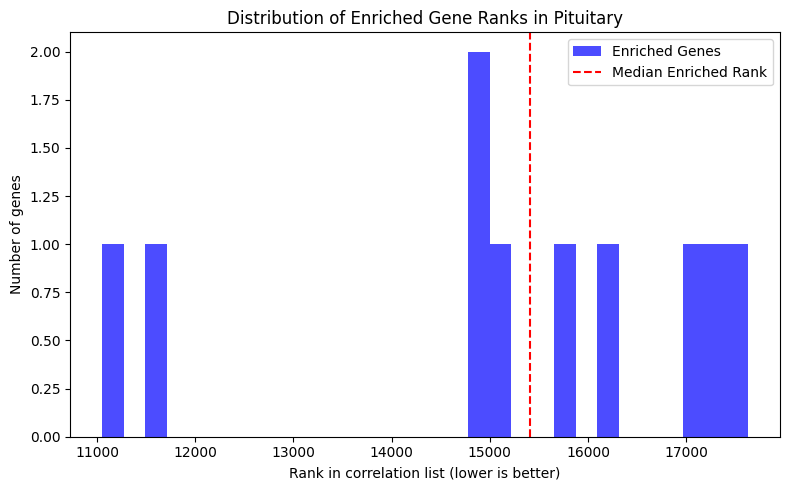

Number of enriched genes for Prostate: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


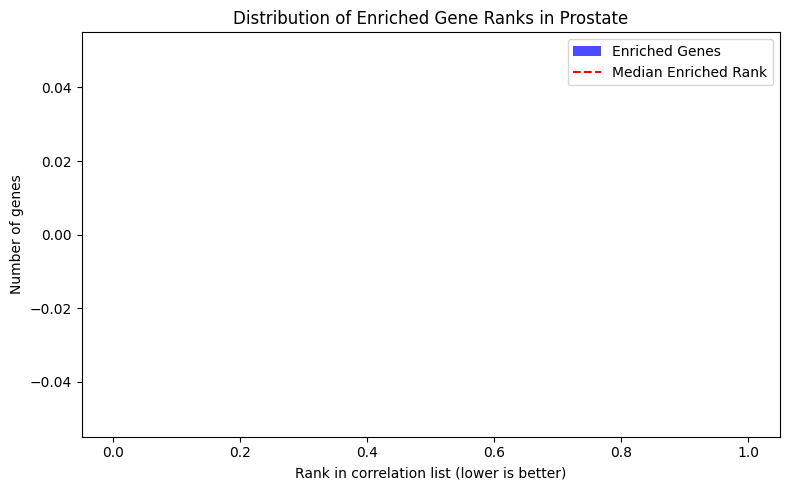

Number of enriched genes for Small Intestine - Terminal Ileum: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


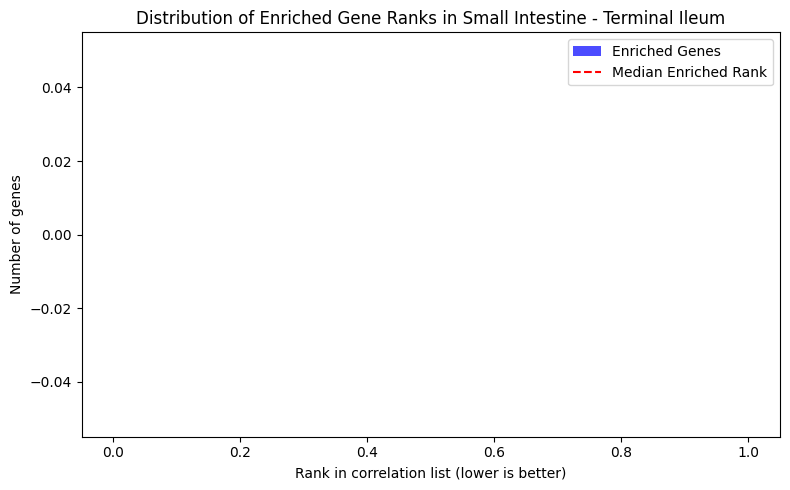

Number of enriched genes for Spleen: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


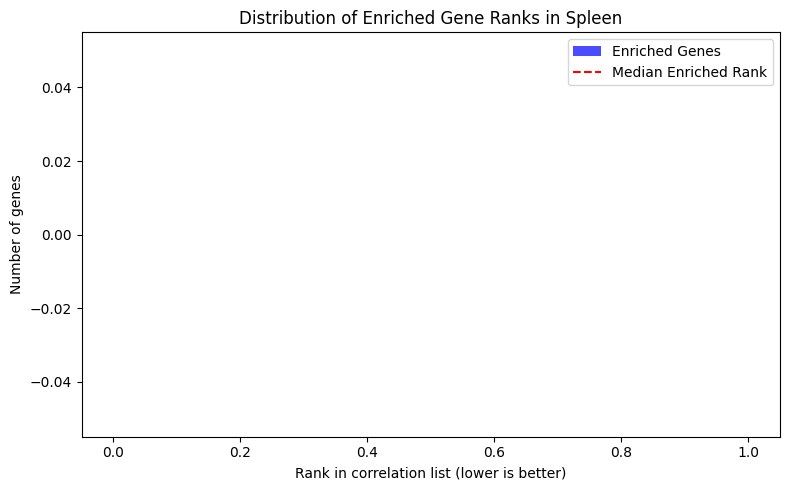

Number of enriched genes for Stomach: 12
Enriched genes found in correlation file: 11
KS statistic: 0.5831, p-value: 4.4035e-04


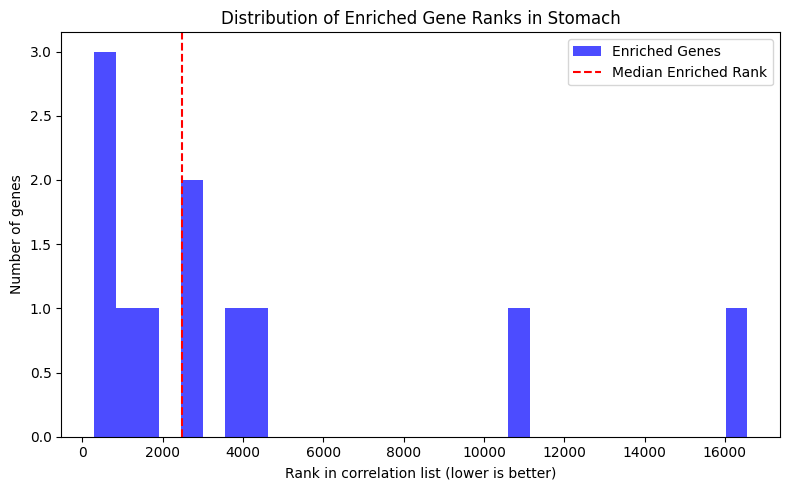

Number of enriched genes for Testis: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


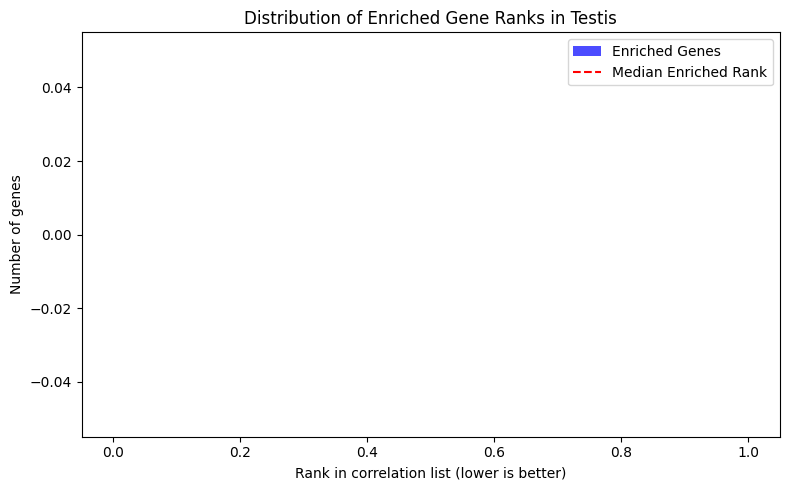

Number of enriched genes for Thyroid: 6
Enriched genes found in correlation file: 6
KS statistic: 0.3844, p-value: 2.6398e-01


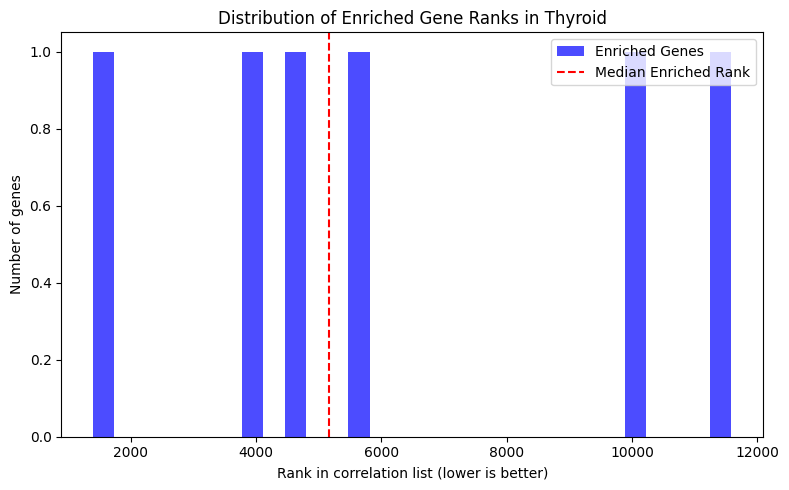

Number of enriched genes for Uterus: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


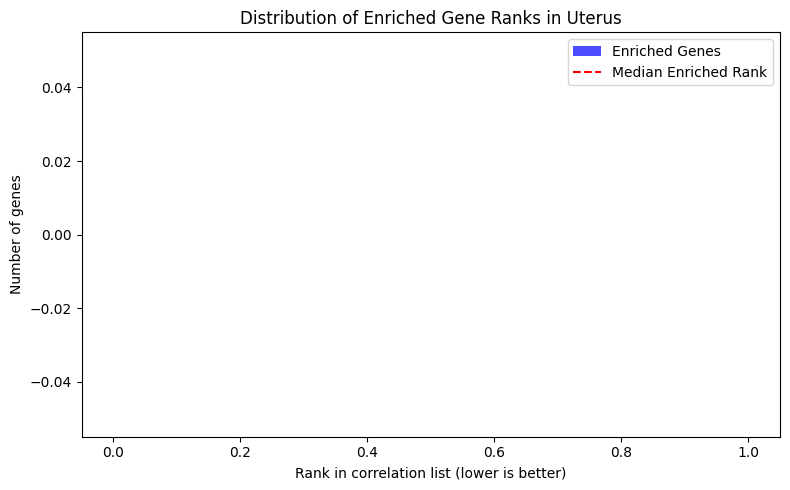

Number of enriched genes for Vagina: 0
Enriched genes found in correlation file: 0
KS statistic: nan, p-value: nan


/tmp/ipykernel_1940543/853471381.py:90: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/apps/Python3/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


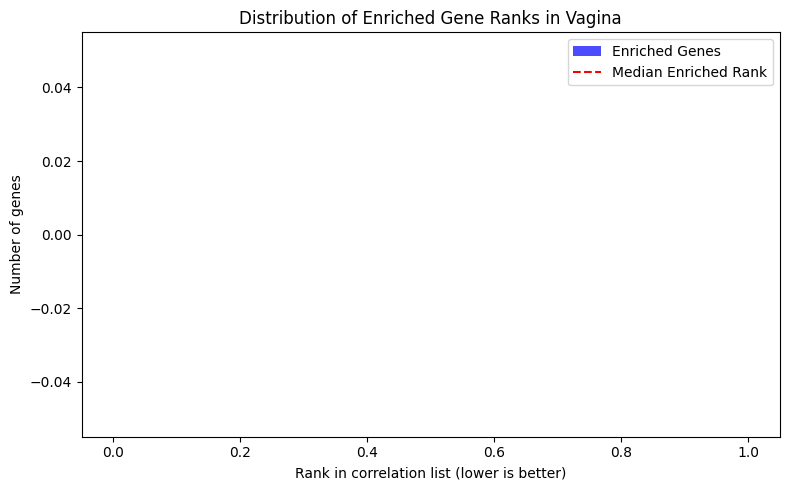

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

path="/shares/sinha/epallapotu/blood_expression_project/41586_2023_6802_MOESM5_ESM.xlsx"
supp3 = pd.read_excel(path, sheet_name='ST3')

# === Load Supplementary Table 3 ===
supp3.columns = [col.strip() for col in supp3.columns]
supp3['GeneName'] = supp3['GeneName'].str.upper()

# === Clean GtexOrgan field ===
def extract_organs(raw_entry):
    if pd.isna(raw_entry):
        return []
    return list(set(x.strip() for x in str(raw_entry).split(',') if x and x.lower() != "nan"))

supp3['Cleaned_Organs'] = supp3['GtexOrgan'].apply(extract_organs)

# === Map vague GtexOrgan values to GTEx tissue names ===
organ_map = {
    "Male": ["Testis", "Prostate"],
    "Female": ["Ovary", "Uterus", "Vagina", "Breast - Mammary Tissue"],
    "Muscle": ["Muscle - Skeletal"],
    "Brain": ["Brain - Cortex", "Brain - Cerebellum"],
    "Esophagus": ["Esophagus - Mucosa", "Esophagus - Muscularis", "Esophagus - Gastroesophageal Junction"],
    "Heart": ["Heart - Left Ventricle", "Heart - Atrial Appendage"],
    "Artery": ["Artery - Aorta", "Artery - Tibial", "Artery - Coronary"],
    "Intestine": ["Small Intestine - Terminal Ileum", "Colon - Sigmoid", "Colon - Transverse"],
    "Adipose": ["Adipose - Subcutaneous"],
    "Kidney": ["Kidney - Cortex"],
    "Salivary": [],
    "Pituitary": ["Pituitary"],
    "Thyroid": ["Thyroid"],
    "Pancreas": ["Pancreas"],
    "Liver": ["Liver"],
    "Lung": ["Lung"],
    "Spleen": ["Spleen"],
    "Bladder": [],
    "Skin": [],
    "Immune": ["Spleen"]
}

def map_to_gtex_tissues(organ_list, mapping):
    gtex_match = []
    for organ in organ_list:
        gtex_match.extend(mapping.get(organ, []))
    return list(set(gtex_match))

supp3['Mapped_GTEx_Tissues'] = supp3['Cleaned_Organs'].apply(lambda x: map_to_gtex_tissues(x, organ_map))

# === Step 1: Choose tissue and extract enriched genes from Supp3 ===
delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
unique_tissues = delta_data["tissue"].unique()

# === Loop through tissues and match top genes ===
for tissue in unique_tissues:
    enriched_genes = supp3[
        (supp3['GtexOrgan'].str.strip().str.lower() == tissue.lower()) &
        (supp3['GtexEnriched'].astype(str).str.lower() == 'true')
    ]['GeneName'].unique()

    print(f"Number of enriched genes for {tissue}: {len(enriched_genes)}")

    # === Step 2: Load correlation data and rank genes ===
    correlation_path = f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_correlation_results.csv"
    cor_df = pd.read_csv(correlation_path, sep=',')

    cor_df['Description'] = cor_df['Description'].str.upper()
    cor_df = cor_df.dropna(subset=['Description', 'Pearson'])

    # Sort by correlation score descending. arl done but double checking here
    cor_df = cor_df.sort_values(by='Pearson', ascending=False).reset_index(drop=True)

    # Step 3: Identify positions of enriched genes in the ranked list. The number one is added since the index starts at zero.
    cor_df['Rank'] = cor_df.index + 1
    cor_df['Is_Enriched'] = cor_df['Description'].isin(enriched_genes) #filter

    # Report overlap
    overlapping_genes = cor_df[cor_df['Is_Enriched']]['Description'].tolist() #list of overlappign genes
    print(f"Enriched genes found in correlation file: {len(overlapping_genes)}")

    # === Step 4: Perform Kolmogorov–Smirnov test ===
    all_ranks = cor_df['Rank']
    enriched_ranks = cor_df[cor_df['Is_Enriched']]['Rank']

    ks_stat, p_value = ks_2samp(enriched_ranks, all_ranks)
    print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4e}")

    # === Step 5: Optional - Plot distribution of ranks ===
    plt.figure(figsize=(8, 5))
    plt.hist(enriched_ranks, bins=30, color='blue', alpha=0.7, label='Enriched Genes')
    plt.axvline(np.median(enriched_ranks), color='red', linestyle='--', label='Median Enriched Rank')
    plt.xlabel("Rank in correlation list (lower is better)")
    plt.ylabel("Number of genes")
    plt.title(f"Distribution of Enriched Gene Ranks in {tissue}")
    plt.legend()
    plt.tight_layout()
    plt.show()


2025-07-30 12:47:21,281 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Number of enriched genes for Adipose - Subcutaneous: 0
skipping tissue type Adipose - Subcutaneous
Number of enriched genes for Adrenal Gland: 0
skipping tissue type Adrenal Gland
Number of enriched genes for Artery - Aorta: 0
skipping tissue type Artery - Aorta
Number of enriched genes for Artery - Coronary: 0
skipping tissue type Artery - Coronary
Number of enriched genes for Artery - Tibial: 0
skipping tissue type Artery - Tibial
Number of enriched genes for Brain - Cerebellum: 0
skipping tissue type Brain - Cerebellum
Number of enriched genes for Brain - Cortex: 0
skipping tissue type Brain - Cortex
Number of enriched genes for Breast - Mammary Tissue: 0
skipping tissue type Breast - Mammary Tissue
Number of enriched genes for Colon - Sigmoid: 0
skipping tissue type Colon - Sigmoid
Number of enriched genes for Colon - Transverse: 0
skipping tissue type Colon - Transverse
Number of enriched genes for Esophagus - Gastroesophageal Junction: 0
skipping tissue type Esophagus - Gastroeso

/tmp/ipykernel_2443322/2833517938.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


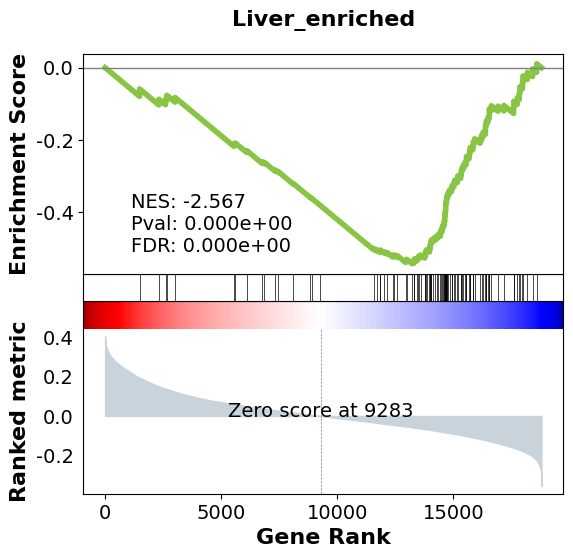

Number of enriched genes for Lung: 9
         ES       NES NOM p-val FDR q-val        Lead_genes
0  0.384671  1.106694  0.316206  0.316206  SFTA2;AGER;CCL18


/tmp/ipykernel_2443322/2833517938.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


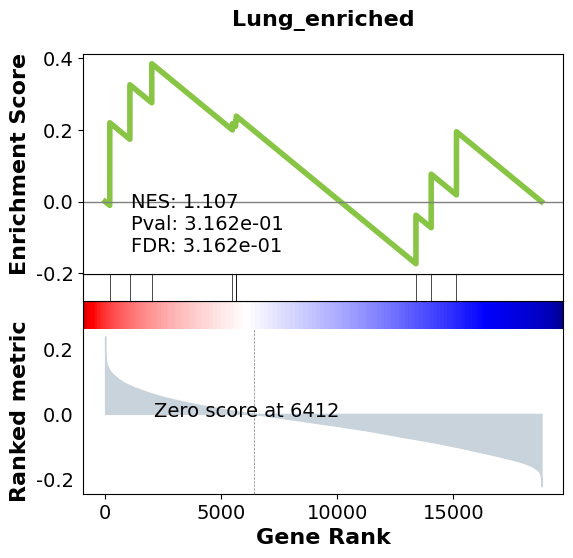

Number of enriched genes for Muscle - Skeletal: 0
skipping tissue type Muscle - Skeletal


2025-07-30 12:47:23,559 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Number of enriched genes for Nerve - Tibial: 0
skipping tissue type Nerve - Tibial
Number of enriched genes for Ovary: 0
skipping tissue type Ovary
Number of enriched genes for Pancreas: 35
         ES       NES NOM p-val FDR q-val  \
0 -0.397096 -1.187508  0.212121  0.212121   

                                          Lead_genes  
0  ERP27;CTRL;KIRREL2;AMY2B;CTRC;SERPINI2;CUZD1;C...  


/tmp/ipykernel_2443322/2833517938.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


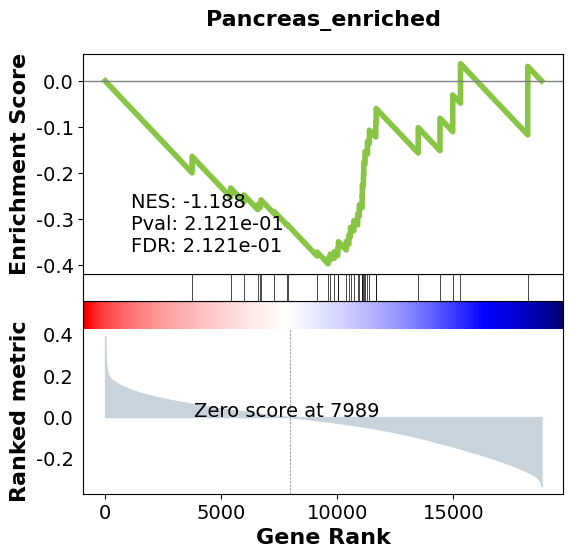

Number of enriched genes for Pituitary: 10


2025-07-30 12:47:24,841 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


         ES       NES NOM p-val FDR q-val                          Lead_genes
0 -0.750646 -2.068135       0.0       0.0  PRL;GH2;FSHB;GH1;LHB;CGA;GAL;NPTX2


/tmp/ipykernel_2443322/2833517938.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


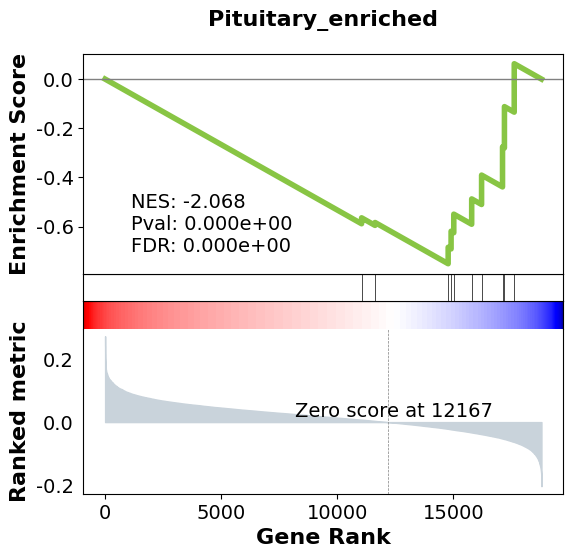

Number of enriched genes for Prostate: 0
skipping tissue type Prostate
Number of enriched genes for Small Intestine - Terminal Ileum: 0
skipping tissue type Small Intestine - Terminal Ileum
Number of enriched genes for Spleen: 0
skipping tissue type Spleen
Number of enriched genes for Stomach: 12
         ES       NES NOM p-val FDR q-val                           Lead_genes
0  0.579192  1.910735  0.004926  0.004926  TFF2;ATP4B;TFF1;MMP1;CHIA;GKN2;GKN1


/tmp/ipykernel_2443322/2833517938.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


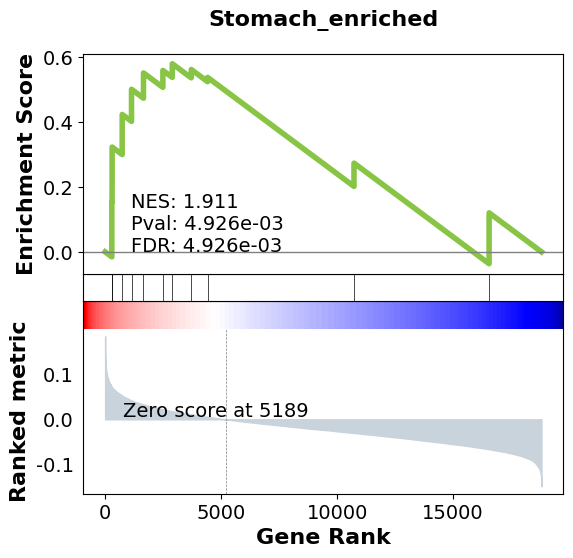

Number of enriched genes for Testis: 0
skipping tissue type Testis
Number of enriched genes for Thyroid: 6
         ES       NES NOM p-val FDR q-val                         Lead_genes
0  0.384509  0.921994  0.547945  0.547945  SLC26A7;PTH;TG;TPO;COL23A1;SLC5A8


/tmp/ipykernel_2443322/2833517938.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


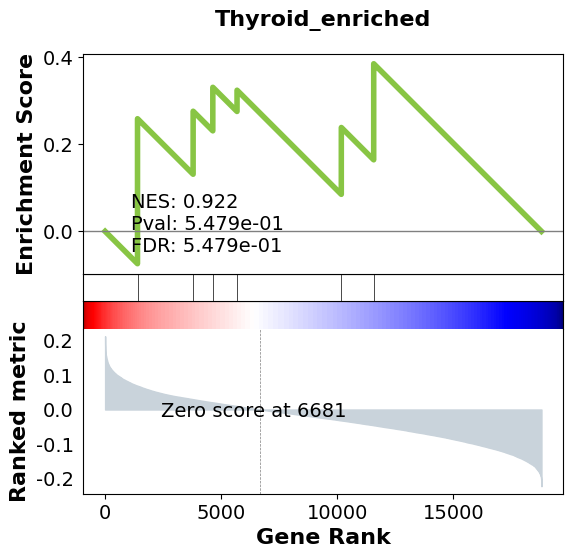

Number of enriched genes for Uterus: 0
skipping tissue type Uterus
Number of enriched genes for Vagina: 0
skipping tissue type Vagina


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import gseapy as gp
from gseapy.plot import gseaplot
path="/shares/sinha/epallapotu/blood_expression_project/41586_2023_6802_MOESM5_ESM.xlsx"
supp3 = pd.read_excel(path, sheet_name='ST3')

# === Load Supplementary Table 3 ===
supp3.columns = [col.strip() for col in supp3.columns]
supp3['GeneName'] = supp3['GeneName'].str.upper()

# === Clean GtexOrgan field ===
def extract_organs(raw_entry):
    if pd.isna(raw_entry):
        return []
    return list(set(x.strip() for x in str(raw_entry).split(',') if x and x.lower() != "nan"))

supp3['Cleaned_Organs'] = supp3['GtexOrgan'].apply(extract_organs)

# === Map vague GtexOrgan values to GTEx tissue names ===
organ_map = {
    "Male": ["Testis", "Prostate"],
    "Female": ["Ovary", "Uterus", "Vagina", "Breast - Mammary Tissue"],
    "Muscle": ["Muscle - Skeletal"],
    "Brain": ["Brain - Cortex", "Brain - Cerebellum"],
    "Esophagus": ["Esophagus - Mucosa", "Esophagus - Muscularis", "Esophagus - Gastroesophageal Junction"],
    "Heart": ["Heart - Left Ventricle", "Heart - Atrial Appendage"],
    "Artery": ["Artery - Aorta", "Artery - Tibial", "Artery - Coronary"],
    "Intestine": ["Small Intestine - Terminal Ileum", "Colon - Sigmoid", "Colon - Transverse"],
    "Adipose": ["Adipose - Subcutaneous"],
    "Kidney": ["Kidney - Cortex"],
    "Salivary": [],
    "Pituitary": ["Pituitary"],
    "Thyroid": ["Thyroid"],
    "Pancreas": ["Pancreas"],
    "Liver": ["Liver"],
    "Lung": ["Lung"],
    "Spleen": ["Spleen"],
    "Bladder": [],
    "Skin": [],
    "Immune": ["Spleen"]
}

def map_to_gtex_tissues(organ_list, mapping):
    gtex_match = []
    for organ in organ_list:
        gtex_match.extend(mapping.get(organ, []))
    return list(set(gtex_match))

supp3['Mapped_GTEx_Tissues'] = supp3['Cleaned_Organs'].apply(lambda x: map_to_gtex_tissues(x, organ_map))

# === Step 1: Choose tissue and extract enriched genes from Supp3 ===
delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
unique_tissues = delta_data["tissue"].unique()

# === Loop through tissues and match top genes ===
for tissue in unique_tissues:
    enriched_genes = supp3[
        (supp3['GtexOrgan'].str.strip().str.lower() == tissue.lower()) &
        (supp3['GtexEnriched'].astype(str).str.lower() == 'true')
    ]['GeneName'].unique()

    print(f"Number of enriched genes for {tissue}: {len(enriched_genes)}")


    if len(enriched_genes)<=5:
        print(f"skipping tissue type {tissue}")
        continue
    else:
        # --- 2. Load and prepare the ranked list for that tissue ---
        corr = pd.read_csv(f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_correlation_results.csv")
        corr['Description'] = corr['Description'].str.upper()
        corr = corr.dropna(subset=['Description','Pearson'])
        corr = corr.drop_duplicates(subset=['Description'])
        corr = corr.sort_values(by='Pearson', ascending=False)

        # Build .rnk object (DataFrame with gene name index and score)
        rnk = corr[['Description','Pearson']].set_index('Description')
        # --- 3. Run preranked GSEA ---
        pre = gp.prerank(
            rnk=rnk,
            gene_sets={f"{tissue}_enriched": enriched_genes},
            outdir=None,
            permutation_num=1000,
            min_size=5,
            max_size=500,
            seed=42
        )

        # Access the results
        res = pre.res2d
        print(res[['ES', 'NES', 'NOM p-val', 'FDR q-val', 'Lead_genes']])


        # --- 4. Create an enrichment plot ---
        term = res.iloc[0]['Term']  # or just 'Pituitary_enriched'
        result = pre.results[term]

        gseaplot(
            rank_metric=pre.ranking,
            term=term,
            hits=result['hits'],
            nes=result['nes'],
            pval=result['pval'],
            fdr=result['fdr'],
            RES=result['RES'],
            ofname=None  # or a file path if you want to save the plot
        )


        # Show plot inline if using notebook
        import matplotlib.pyplot as plt
        plt.tight_layout()
        plt.show()


In [ ]:
print(res.columns)
print(res.head())


Index(['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val',
       'Tag %', 'Gene %', 'Lead_genes'],
      dtype='object')
      Name                Term        ES       NES NOM p-val FDR q-val  \
0  prerank  Pituitary_enriched -0.750646 -2.068135       0.0       0.0   

  FWER p-val Tag %  Gene %                          Lead_genes  
0        0.0  8/10  21.39%  PRL;GH2;FSHB;GH1;LHB;CGA;GAL;NPTX2  


In [ ]:
cor_df

,Pearson,P_value,Name,Description
0,-0.034785,0.566417,ENSG00000186092.7,OR4F5
1,-0.069920,0.248702,ENSG00000284733.2,OR4F29
2,-0.019115,0.752768,ENSG00000284662.2,OR4F16
3,-0.044237,0.465845,ENSG00000187634.13,SAMD11
4,0.029570,0.626014,ENSG00000188976.11,NOC2L
...,...,...,...,...
18912,-0.041944,0.489300,ENSG00000212907.2,MT-ND4L
18913,-0.030041,0.620526,ENSG00000198886.2,MT-ND4
18914,-0.052848,0.383532,ENSG00000198786.2,MT-ND5
18915,-0.078401,0.195725,ENSG00000198695.2,MT-ND6


In [ ]:
import pandas as pd

# === Load Supplementary Table 3 ===
supp3.columns = [col.strip() for col in supp3.columns]     # Clean column names
supp3['GeneName'] = supp3['GeneName'].str.upper()          # Clean gene names

# === Clean GtexOrgan field ===
def extract_organs(raw_entry):
    if pd.isna(raw_entry):
        return []
    return list(set(x.strip() for x in str(raw_entry).split(',') if x and x.lower() != "nan"))

supp3['Cleaned_Organs'] = supp3['GtexOrgan'].apply(extract_organs)

# === Map vague GtexOrgan values to GTEx tissue names ===
organ_map = {
    "Male": ["Testis", "Prostate"],
    "Female": ["Ovary", "Uterus", "Vagina", "Breast - Mammary Tissue"],
    "Muscle": ["Muscle - Skeletal"],
    "Brain": ["Brain - Cortex", "Brain - Cerebellum"],
    "Esophagus": ["Esophagus - Mucosa", "Esophagus - Muscularis", "Esophagus - Gastroesophageal Junction"],
    "Heart": ["Heart - Left Ventricle", "Heart - Atrial Appendage"],
    "Artery": ["Artery - Aorta", "Artery - Tibial", "Artery - Coronary"],
    "Intestine": ["Small Intestine - Terminal Ileum", "Colon - Sigmoid", "Colon - Transverse"],
    "Adipose": ["Adipose - Subcutaneous"],
    "Kidney": ["Kidney - Cortex"],
    "Salivary": [],
    "Pituitary": ["Pituitary"],
    "Thyroid": ["Thyroid"],
    "Pancreas": ["Pancreas"],
    "Liver": ["Liver"],
    "Lung": ["Lung"],
    "Spleen": ["Spleen"],
    "Bladder": [],
    "Skin": [],
    "Immune": ["Spleen"]
}

def map_to_gtex_tissues(organ_list, mapping):
    gtex_match = []
    for organ in organ_list:
        gtex_match.extend(mapping.get(organ, []))
    return list(set(gtex_match))

supp3['Mapped_GTEx_Tissues'] = supp3['Cleaned_Organs'].apply(lambda x: map_to_gtex_tissues(x, organ_map))

# === Load delta score data ===
delta_data = pd.read_csv('/shares/sinha/epallapotu/blood_expression_project/all_tissues_delta_scores.tsv', sep='\t')
#unique_tissues = delta_data["tissue"].unique()

specific_unique_tissues=["Adrenal Gland", "Esophagus - Mucosa", "Heart - Atrial Appendage", "Heart - Left Ventricle", "Kidney - Cortex", "Liver", "Lung", "Muscle - Skeletal", "Pancreas", "Small Intestine - Terminal Ileum", "Thyroid"]
# === Loop through tissues and match top genes ===
for tissue in specific_unique_tissues:
    print(f"\n--- {tissue.upper()} ---")

    # Load top gene list for this tissue as a list of uppercase gene names
    file_path = f"/shares/sinha/epallapotu/blood_expression_project/{tissue}_analysis_results/{tissue}_geneDescription.txt"
    top_gene_names = pd.read_csv(file_path, header=None)[0].str.upper().head(2000).tolist()

    # Filter supp3 to matching genes
    matches = supp3[supp3['GeneName'].isin(top_gene_names)].copy()

    # Check whether mapped GTEx tissues include this tissue
    def matches_tissue(mapped_tissues, tissue_name):
        return any(tissue_name.lower() in mt.lower() for mt in mapped_tissues)

    matches['Is_Tissue_Expressed'] = matches['Mapped_GTEx_Tissues'].apply(lambda x: matches_tissue(x, tissue))

    matches_tissue_specific = matches[matches['Is_Tissue_Expressed']]

    if 'GtexEnriched' in matches_tissue_specific.columns:
        matches_tissue_enriched = matches_tissue_specific[matches_tissue_specific['GtexEnriched'] == 'True']
    else:
        matches_tissue_enriched = pd.DataFrame()


    # Output stats
    print(f"Top genes: {len(top_gene_names)}")
    print(f"Matched in Supp3: {len(matches)}")
    print(f"Expressed in {tissue}: {len(matches_tissue_specific)}")
    print(f"Enriched in {tissue}: {len(matches_tissue_enriched)}")

    if not matches_tissue_enriched.empty:
        print(matches_tissue_enriched[['GeneName', 'GtexOrgan', 'GtexFoldChange']])





--- ADRENAL GLAND ---
Top genes: 2000
Matched in Supp3: 568
Expressed in Adrenal Gland: 0
Enriched in Adrenal Gland: 0

--- ESOPHAGUS - MUCOSA ---
Top genes: 2000
Matched in Supp3: 464
Expressed in Esophagus - Mucosa: 15
Enriched in Esophagus - Mucosa: 0

--- HEART - ATRIAL APPENDAGE ---
Top genes: 2000
Matched in Supp3: 550
Expressed in Heart - Atrial Appendage: 3
Enriched in Heart - Atrial Appendage: 0

--- HEART - LEFT VENTRICLE ---
Top genes: 2000
Matched in Supp3: 628
Expressed in Heart - Left Ventricle: 4
Enriched in Heart - Left Ventricle: 0

--- KIDNEY - CORTEX ---
Top genes: 2000
Matched in Supp3: 623
Expressed in Kidney - Cortex: 31
Enriched in Kidney - Cortex: 1
     GeneName GtexOrgan    GtexFoldChange
4858  TMEM52B    Kidney  75.7476778388176

--- LIVER ---
Top genes: 2000
Matched in Supp3: 628
Expressed in Liver: 19
Enriched in Liver: 2
    GeneName GtexOrgan      GtexFoldChange
147   INSIG1     Liver   4.368135022641295
933    RDH16     Liver  46.620275605642284

--- LU